# Module 6A — Portfolio Returns and Risk: Two-Stock Intuition
## Notebook 6A (teaching edition): Building a 2-stock portfolio by hand and reading its risk off the return series

So far each stock has lived in its own column. In this short notebook we **combine two stocks into a portfolio** and ask the most basic question:

> *Once you blend two stocks at fixed weights, what does the resulting portfolio look like — and is it riskier or safer than the stocks themselves?*

The pedagogy here is deliberately old-school:

1. Load the two stocks and compute their monthly returns.
2. Pick the weights **by hand** (no optimisation, no formula yet).
3. Compute the **portfolio return for every month** as $w_1 r_{1,t} + w_2 r_{2,t}$ — this is just a new return series.
4. Compute the portfolio's **standard deviation directly from that series** with `.std()` — no $\mathbf{w}^\top \Sigma \mathbf{w}$ yet.
5. Compare the portfolio's std with each stock's own std, and notice what happens.

We deliberately **do not** use the variance formula $\sigma_p^2 = w_1^2\sigma_1^2 + w_2^2\sigma_2^2 + 2 w_1 w_2 \sigma_1 \sigma_2 \rho$ here. That formula will come later, in Notebook 6B, once we want to *sweep over many weights at once*. For a single fixed weight choice, the return series is right in front of us — there is no reason to compute its std any way other than directly.

We use **Reliance** (a low-vol large-cap) and **Poonawalla Fincorp** (a high-vol mid-cap NBFC). The contrast in their volatilities makes the diversification effect easy to see.


## 0. Imports and configuration


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.precision', 4)


## 1. Load the two stocks and compute monthly returns

Both files come from the monthly OHLCV data prepared in Notebook 0. We need only the **Close** column. From Close we compute simple monthly returns

$$
r_t \;=\; \frac{P_t - P_{t-1}}{P_{t-1}},
$$

and convert to **percent** so the numbers are easier to read.


In [2]:
reliance_raw   = pd.read_csv('datasets/monthly/RELIANCE_NS.csv',   index_col='Date', parse_dates=True)
poonawalla_raw = pd.read_csv('datasets/monthly/POONAWALLA_NS.csv', index_col='Date', parse_dates=True)

returns = pd.DataFrame({
    'RELIANCE':   reliance_raw['Close'].pct_change()   * 100,
    'POONAWALLA': poonawalla_raw['Close'].pct_change() * 100,
}).dropna()

print(f'Aligned monthly returns: n = {len(returns)}')
print(f'Range: {returns.index.min().date()} to {returns.index.max().date()}')
returns.head()


Aligned monthly returns: n = 59
Range: 2021-06-01 to 2026-04-01


,RELIANCE,POONAWALLA
Date,,
2021-06-01,-2.2983,7.9692
2021-07-01,-3.2338,18.0272
2021-08-01,10.9492,-0.3170
2021-09-01,11.5625,-5.8109
2021-10-01,0.6748,1.7802


## 2. What does each stock look like on its own?

Two summary numbers per stock:

- **Mean** monthly return — average reward per month.
- **Standard deviation** of monthly returns — our usual proxy for risk.

These are computed directly from the return columns.


In [3]:
mean_rel,  mean_poon  = returns['RELIANCE'].mean(),  returns['POONAWALLA'].mean()
sd_rel,    sd_poon    = returns['RELIANCE'].std(),   returns['POONAWALLA'].std()

summary = pd.DataFrame({
    'mean (% per month)': [mean_rel,  mean_poon],
    'std (% per month)':  [sd_rel,    sd_poon],
}, index=['RELIANCE', 'POONAWALLA'])
summary.round(4)


,mean (% per month),std (% per month)
RELIANCE,0.6998,5.7886
POONAWALLA,2.5180,10.9131


**What to notice.** Poonawalla has a much higher std than Reliance — it is the riskier of the two. Hold this picture in mind: the question is whether *blending* the two into a portfolio puts the resulting risk somewhere between these two numbers, or somewhere outside that range.


## 3. Pick the weights by hand

We choose the weights ourselves — no optimisation. The only rule is that they must sum to 1 (we are fully invested) and we will keep both non-negative (no short selling).

Try a **60% Reliance / 40% Poonawalla** mix. (You should re-run the notebook with other choices — 50/50, 80/20, 30/70 — and see how the answer moves.)


In [4]:
w_rel  = 0.60
w_poon = 0.40
assert np.isclose(w_rel + w_poon, 1.0), 'Weights must sum to 1.'

print(f'w_RELIANCE   = {w_rel:.2f}')
print(f'w_POONAWALLA = {w_poon:.2f}')


w_RELIANCE   = 0.60
w_POONAWALLA = 0.40


## 4. Build the portfolio return series

For a fixed pair of weights, the portfolio return in month $t$ is

$$
r_{p,t} \;=\; w_1\, r_{1,t} \;+\; w_2\, r_{2,t}.
$$

Apply this **row by row** to the two return columns and we get a new return series — one number per month — that is just as much a return series as any single stock's.


In [5]:
port_returns = w_rel * returns['RELIANCE'] + w_poon * returns['POONAWALLA']
port_returns.name = 'PORTFOLIO'

print(f'Portfolio return observations: {len(port_returns)}')
port_returns.head()


Portfolio return observations: 59


Date
2021-06-01    1.8087
2021-07-01    5.2706
2021-08-01    6.4427
2021-09-01    4.6132
2021-10-01    1.1170
Name: PORTFOLIO, dtype: float64

That column is the new asset we just constructed. From here on we treat it like any other return series.


## 5. Portfolio risk — standard deviation **directly** from the portfolio returns

Since the portfolio is just another return series, its risk is just the std of that series:

```python
port_returns.std()
```

That's it. **No variance formula, no covariance matrix, no $\sigma_p^2 = \mathbf{w}^\top \Sigma \mathbf{w}$.** We will get to those tools in Notebook 6B, where they earn their keep when we want to sweep over many weight choices at once. Here we only have one portfolio, and its return series is sitting right in front of us — so we read its std off the series.


In [6]:
mean_port = port_returns.mean()
sd_port   = port_returns.std()

print(f'Portfolio mean return: {mean_port:+.4f}% per month')
print(f'Portfolio std:         {sd_port:.4f}% per month')


Portfolio mean return: +1.4271% per month
Portfolio std:         6.4655% per month


## 6. Compare the portfolio's risk with the individual stocks

Put all three numbers side by side.


In [7]:
compare = pd.DataFrame({
    'mean (% per month)': [mean_rel,  mean_poon,  mean_port],
    'std (% per month)':  [sd_rel,    sd_poon,    sd_port],
}, index=['RELIANCE (100%)',
          'POONAWALLA (100%)',
          f'Portfolio ({int(w_rel*100)}/{int(w_poon*100)})'])
compare.round(4)


,mean (% per month),std (% per month)
RELIANCE (100%),0.6998,5.7886
POONAWALLA (100%),2.5180,10.9131
Portfolio (60/40),1.4271,6.4655


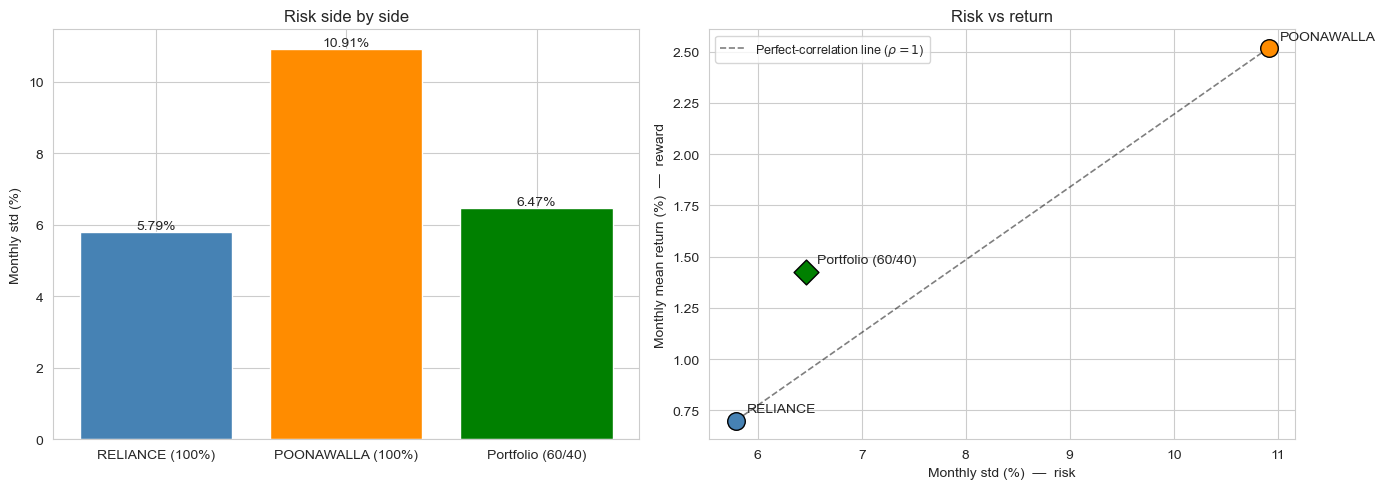

In [8]:
# Two views of the same comparison: bars on the left, risk-return scatter on the right
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

labels = compare.index
means  = compare['mean (% per month)'].values
sds    = compare['std (% per month)'].values
colors = ['steelblue', 'darkorange', 'green']

# Left — std bar chart
bars = ax1.bar(labels, sds, color=colors)
for bar, v in zip(bars, sds):
    ax1.text(bar.get_x() + bar.get_width()/2, v, f'{v:.2f}%',
             ha='center', va='bottom', fontsize=10)
ax1.set_ylabel('Monthly std (%)')
ax1.set_title('Risk side by side')

# Right — risk-return scatter
markers = ['o', 'o', 'D']
short = ['RELIANCE', 'POONAWALLA', f'Portfolio ({int(w_rel*100)}/{int(w_poon*100)})']
for name, s, m, color, marker in zip(short, sds, means, colors, markers):
    ax2.scatter(s, m, s=160, color=color, marker=marker, edgecolor='black', zorder=5)
    ax2.annotate(name, (s, m), xytext=(8, 6), textcoords='offset points', fontsize=10)

# Straight line from RELIANCE to POONAWALLA — where the portfolio would sit if rho = 1.
ax2.plot([sds[0], sds[1]], [means[0], means[1]],
         'k--', alpha=0.5, linewidth=1.2,
         label=r'Perfect-correlation line ($\rho = 1$)')

ax2.set_xlabel('Monthly std (%)  —  risk')
ax2.set_ylabel('Monthly mean return (%)  —  reward')
ax2.set_title('Risk vs return')
ax2.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()


## 7. Cross-check — with variance formula

Computing `port_returns.std()` is the **direct** way: build the portfolio's return series first, then take its std.

There is also a **formula** way. For a two-stock portfolio,

$$
\sigma_p^2 \;=\; w_1^2 \sigma_1^2 \;+\; w_2^2 \sigma_2^2 \;+\; 2\, w_1 w_2 \,\sigma_1 \sigma_2 \,\rho_{12}.
$$

Each term has a meaning:

- $w_1^2 \sigma_1^2$ — Reliance's contribution (its own variance, scaled by its weight squared).
- $w_2^2 \sigma_2^2$ — Poonawalla's contribution.
- $2 w_1 w_2 \sigma_1 \sigma_2 \rho_{12}$ — the **interaction** term. This is where the diversification math lives: when $\rho_{12} < 1$, the interaction is smaller than it would be at perfect correlation, and the portfolio variance comes out lower than a naive blend would suggest.

We compute each piece by hand and compare with the direct std.


In [9]:
# Inputs we already have
rho = returns['RELIANCE'].corr(returns['POONAWALLA'])

# Each term of the formula, computed separately so we can read them
term_rel    = w_rel**2  * sd_rel**2
term_poon   = w_poon**2 * sd_poon**2
term_cross  = 2 * w_rel * w_poon * sd_rel * sd_poon * rho

var_p_formula = term_rel + term_poon + term_cross
sd_p_formula  = np.sqrt(var_p_formula)

print(f'correlation  rho   = {rho:.4f}')
print()
print(f'  w1^2 * s1^2                   = {term_rel:.4f}')
print(f'  w2^2 * s2^2                   = {term_poon:.4f}')
print(f'  2 * w1*w2 * s1*s2 * rho       = {term_cross:.4f}')
print(f'  --------------------------------------')
print(f'  variance (formula)            = {var_p_formula:.4f}')
print(f'  std      (formula, sqrt)      = {sd_p_formula:.4f}%')
print()
print(f'  std      (direct, .std())     = {sd_port:.4f}%')
print()
print(f'  match within float tolerance? {np.isclose(sd_p_formula, sd_port)}')


correlation  rho   = 0.3524

  w1^2 * s1^2                   = 12.0629
  w2^2 * s2^2                   = 19.0555
  2 * w1*w2 * s1*s2 * rho       = 10.6847
  --------------------------------------
  variance (formula)            = 41.8031
  std      (formula, sqrt)      = 6.4655%

  std      (direct, .std())     = 6.4655%

  match within float tolerance? True


**What this confirms.** The two methods give the same number — they have to, because they're computing the standard deviation of the same series ($w_1 r_1 + w_2 r_2$), just along different paths. The direct method *is* the definition; the formula is an algebraic shortcut that lets you compute the same answer from $\sigma_1$, $\sigma_2$, and $\rho_{12}$ alone, without rebuilding the return series.

Why bother with the formula, then? **Speed.** When you want to compare *many* weight choices — sweep through 100 of them, simulate 5,000 random portfolios, run an optimiser — the direct method has to rebuild a fresh return series each time. The formula reads off a few precomputed numbers ($\sigma_1$, $\sigma_2$, $\rho_{12}$) and is essentially free.


## 8. Closing thought — what comes next

We answered the basic question: blending two stocks reduces the portfolio's risk, and we saw it both ways — by reading the std off the portfolio return series, and by computing it from the textbook variance formula. They agree exactly, as they must.

The natural next questions are:

- *What is the **best** weight choice?* — minimum-variance, or maximum-Sharpe?
- *What does the whole **range** of weight choices look like as a curve in (risk, return) space?*

To answer those we need to evaluate the portfolio's risk for **many** weight choices in one shot. The formula we just verified generalises directly to the matrix form

$$
\sigma_p^2 \;=\; \mathbf{w}^\top \Sigma \mathbf{w},
$$

which handles any number of stocks at once and is fast enough to plug into an optimiser. Notebook 6B picks up the story there.
